In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, ttest_ind, f_oneway

In [28]:
lok = pd.read_csv("ind-lok-sabha.csv")
vid = pd.read_csv("ind-vidhan-sabha.csv")

In [29]:
lok.head()

,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,K.R. Ganesh,M,Independents,IND,25168,85308
1,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,Manoranjan Bhakta,M,Indian National Congress,INC,35400,85308
2,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Ramesh Mazumdar,M,Independents,IND,109,96084
3,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Alagiri Swamy,M,Independents,IND,125,96084
4,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Kannu Chemy,M,Independents,IND,405,96084


In [30]:
print("Lok Sabha Dataset")
display(lok.head())

print("Vidhan Sabha Dataset")
display(vid.head())

Lok Sabha Dataset


,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,K.R. Ganesh,M,Independents,IND,25168,85308
1,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,Manoranjan Bhakta,M,Indian National Congress,INC,35400,85308
2,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Ramesh Mazumdar,M,Independents,IND,109,96084
3,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Alagiri Swamy,M,Independents,IND,125,96084
4,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Kannu Chemy,M,Independents,IND,405,96084


Vidhan Sabha Dataset


,st_name,year,ac_no,ac_name,ac_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Manabala Ramarao,M,Independent,IND,813.0,83247
1,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Appadu Sahu,M,Independent,IND,1743.0,83247
2,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Uppada Rangababu,M,Indian National Congress,INC,4427.0,83247
3,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Kalla Balarama Swamy,M,Indian National Congress (I),INC(I),19805.0,83247
4,Andhra Pradesh,1978.0,1,Ichapuram,GEN,Bendalam Venkatesam Sarma,M,Janata Party,JNP,34251.0,83247


In [31]:
print("Lok Sabha Shape :", lok.shape)
print("Vidhan Sabha Shape :", vid.shape)

Lok Sabha Shape : (73081, 11)
Vidhan Sabha Shape : (327294, 11)


In [32]:
print("Lok Sabha Info")
lok.info()

print("\nVidhan Sabha Info")
vid.info()

Lok Sabha Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73081 entries, 0 to 73080
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   st_name     73081 non-null  object
 1   year        73081 non-null  int64 
 2   pc_no       73081 non-null  int64 
 3   pc_name     73081 non-null  object
 4   pc_type     65011 non-null  object
 5   cand_name   73081 non-null  object
 6   cand_sex    72539 non-null  object
 7   partyname   73081 non-null  object
 8   partyabbre  73081 non-null  object
 9   totvotpoll  73081 non-null  int64 
 10  electors    73081 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 6.1+ MB

Vidhan Sabha Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327294 entries, 0 to 327293
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   st_name     327294 non-null  object 
 1   year        327294 non-null  float64
 2   ac_

In [33]:
print("Lok Sabha Missing Values")
print(lok.isnull().sum())

print("\nVidhan Sabha Missing Values")
print(vid.isnull().sum())

Lok Sabha Missing Values
st_name          0
year             0
pc_no            0
pc_name          0
pc_type       8070
cand_name        0
cand_sex       542
partyname        0
partyabbre       0
totvotpoll       0
electors         0
dtype: int64

Vidhan Sabha Missing Values
st_name           0
year              0
ac_no             0
ac_name       16083
ac_type           0
cand_name         0
cand_sex       5302
partyname         0
partyabbre     2706
totvotpoll        7
electors          0
dtype: int64


In [34]:
mapping = (
    vid.groupby("partyname")["partyabbre"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

vid["partyabbre"] = vid["partyabbre"].fillna(
    vid["partyname"].map(mapping)
)

vid["partyabbre"] = vid["partyabbre"].fillna("IND")

In [35]:
vid["partyabbre"] = vid["partyabbre"].replace({
    "INC(I)": "INC"
})

lok["partyabbre"] = lok["partyabbre"].replace({
    "INC(I)": "INC"
})

In [23]:
lok["year"] = lok["year"].astype(int)
vid["year"] = vid["year"].astype(int)

In [24]:
lok["pc_type"] = lok["pc_type"].fillna("Unknown")

In [25]:
lok = lok.dropna(subset=["totvotpoll"])
vid = vid.dropna(subset=["totvotpoll"])

In [37]:
# Create mapping
ac_map = (
    vid.groupby(["st_name", "ac_no"])["ac_name"]
       .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
       .to_dict()
)

# Fill missing ac_name
vid["ac_name"] = vid.apply(
    lambda row: ac_map.get((row["st_name"], row["ac_no"]), row["ac_name"])
    if pd.isna(row["ac_name"]) else row["ac_name"],
    axis=1
)

print("Remaining Missing:", vid["ac_name"].isnull().sum())

Remaining Missing: 0


Question 1: Party Abbreviation Cleaning

In [38]:
# Create mapping of party name to most frequently used abbreviation

party_mapping = (
    vid.groupby("partyname")["partyabbre"]
       .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

# Fill missing abbreviations
vid["partyabbre"] = vid["partyabbre"].fillna(
    vid["partyname"].map(party_mapping)
)

# Fill remaining missing values with IND
vid["partyabbre"] = vid["partyabbre"].fillna("IND")

# Check missing values
print("Remaining Missing Party Abbreviations:")
print(vid["partyabbre"].isnull().sum())

Remaining Missing Party Abbreviations:
0


Question 2: Standardize Party Abbreviations

In [39]:
# Replace inconsistent abbreviations

vid["partyabbre"] = vid["partyabbre"].replace({
    "INC(I)": "INC"
})

lok["partyabbre"] = lok["partyabbre"].replace({
    "INC(I)": "INC"
})

print("Party abbreviations standardized successfully.")

Party abbreviations standardized successfully.


Question 3: Data Type & Missing Value Handling

In [40]:
# Convert year to integer
vid["year"] = vid["year"].astype(int)
lok["year"] = lok["year"].astype(int)

# Fill missing candidate gender
vid["cand_sex"] = vid["cand_sex"].fillna("U")
lok["cand_sex"] = lok["cand_sex"].fillna("U")

# Drop rows with missing total votes polled
vid = vid.dropna(subset=["totvotpoll"])
lok = lok.dropna(subset=["totvotpoll"])

print("Missing value handling completed.")

Missing value handling completed.


Question 4: Filling Missing Assembly Names

In [41]:
# Create mapping
ac_map = (
    vid.groupby(["st_name", "ac_no"])["ac_name"]
       .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
       .to_dict()
)

# Fill missing assembly names
vid["ac_name"] = vid.apply(
    lambda row: ac_map.get((row["st_name"], row["ac_no"]), row["ac_name"])
    if pd.isna(row["ac_name"]) else row["ac_name"],
    axis=1
)

print("Remaining Missing Assembly Names:")
print(vid["ac_name"].isnull().sum())

Remaining Missing Assembly Names:
0


Question 5: Initial Data Exploration – Lok Sabha Dataset

In [42]:
print("Dataset Shape:")
print(lok.shape)

Dataset Shape:
(73081, 11)


In [43]:
lok.head()

,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,K.R. Ganesh,M,Independents,IND,25168,85308
1,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,Manoranjan Bhakta,M,Indian National Congress,INC,35400,85308
2,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Ramesh Mazumdar,M,Independents,IND,109,96084
3,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Alagiri Swamy,M,Independents,IND,125,96084
4,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Kannu Chemy,M,Independents,IND,405,96084


In [44]:
lok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73081 entries, 0 to 73080
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   st_name     73081 non-null  object
 1   year        73081 non-null  int64 
 2   pc_no       73081 non-null  int64 
 3   pc_name     73081 non-null  object
 4   pc_type     65011 non-null  object
 5   cand_name   73081 non-null  object
 6   cand_sex    73081 non-null  object
 7   partyname   73081 non-null  object
 8   partyabbre  73081 non-null  object
 9   totvotpoll  73081 non-null  int64 
 10  electors    73081 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 6.1+ MB


In [45]:
lok.isnull().sum()

st_name          0
year             0
pc_no            0
pc_name          0
pc_type       8070
cand_name        0
cand_sex         0
partyname        0
partyabbre       0
totvotpoll       0
electors         0
dtype: int64

Question 6: Handling Missing Values – Lok Sabha Dataset

In [46]:
lok["cand_sex"] = lok["cand_sex"].fillna("U")

lok["pc_type"] = lok["pc_type"].fillna("Unknown")

print(lok.isnull().sum())

st_name       0
year          0
pc_no         0
pc_name       0
pc_type       0
cand_name     0
cand_sex      0
partyname     0
partyabbre    0
totvotpoll    0
electors      0
dtype: int64


Question 7: Standardizing Party Abbreviations – Lok Sabha Dataset

In [47]:
lok["partyabbre"] = lok["partyabbre"].replace({
    "INC(I)": "INC"
})

print(lok["partyabbre"].value_counts().head())

partyabbre
IND    41127
INC     5292
BJP     3350
BSP     2624
SP      1057
Name: count, dtype: int64


Question 8: Basic Summary Statistics – Vidhan Sabha Dataset

In [48]:
print("Unique States")
print(vid["st_name"].nunique())

print("Unique Years")
print(vid["year"].nunique())

print("Unique Assembly Constituencies")
print(vid["ac_no"].nunique())

print("Unique Candidates")
print(vid["cand_name"].nunique())

print("Unique Parties")
print(vid["partyabbre"].nunique())

Unique States
30
Unique Years
36
Unique Assembly Constituencies
425
Unique Candidates
220529
Unique Parties
1284


Question 9: Candidate Gender Distribution – Visualization

cand_sex
M    307091
F     14883
U      5302
O        11
Name: count, dtype: int64


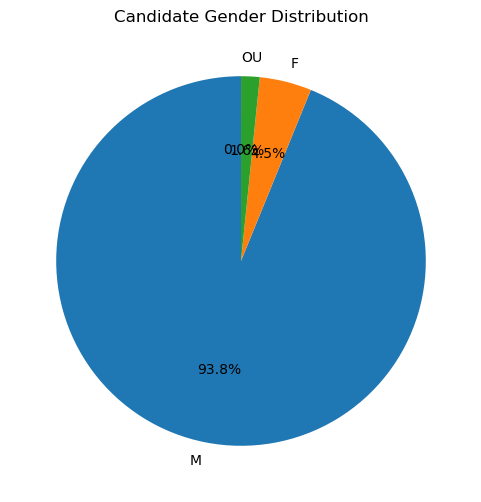

In [49]:
gender_count = vid["cand_sex"].value_counts()

print(gender_count)

plt.figure(figsize=(6,6))
plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Candidate Gender Distribution")
plt.show()

Question 10: Trend of Average Candidates per Seat

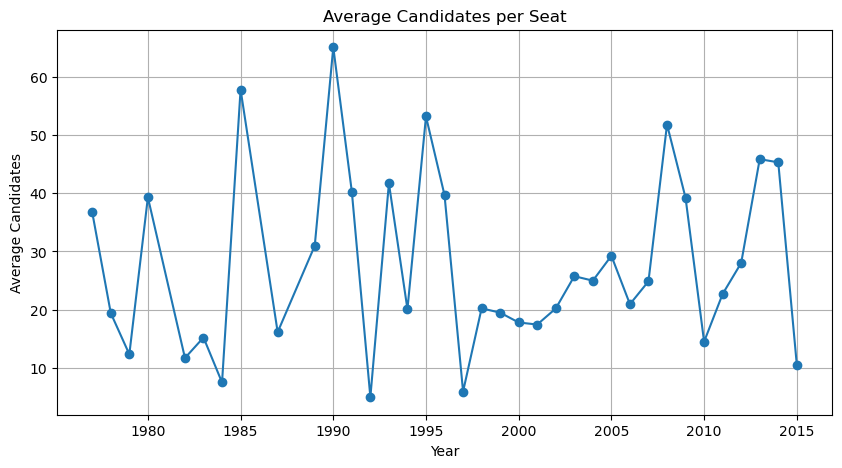

In [50]:
candidate_per_seat = (
    vid.groupby(["year","ac_no"])["cand_name"]
       .nunique()
       .reset_index(name="Candidates")
)

avg_candidate = (
    candidate_per_seat.groupby("year")["Candidates"]
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(avg_candidate.index,
         avg_candidate.values,
         marker='o')

plt.title("Average Candidates per Seat")
plt.xlabel("Year")
plt.ylabel("Average Candidates")
plt.grid(True)

plt.show()

Question 11: Voter Turnout Analysis by Year

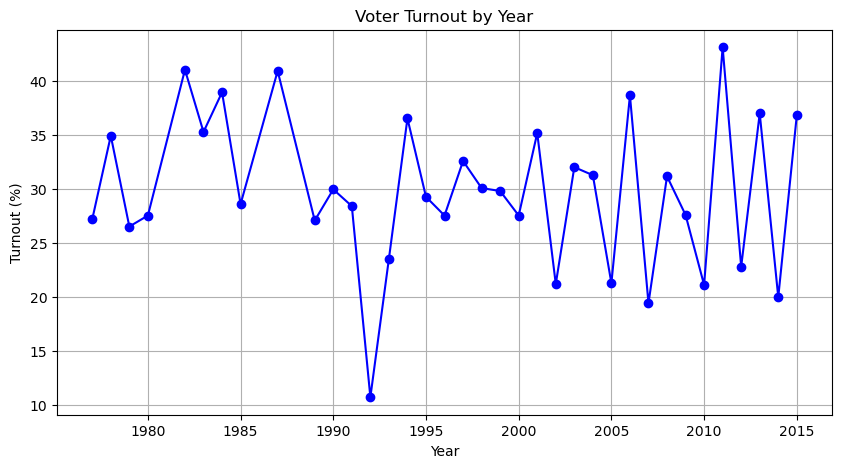

In [51]:
turnout = (
    vid.groupby(["year","ac_no"])
    .agg({
        "totvotpoll":"max",
        "electors":"max"
    })
    .reset_index()
)

yearly = turnout.groupby("year").sum()

yearly["Turnout"] = (
    yearly["totvotpoll"] /
    yearly["electors"] * 100
)

plt.figure(figsize=(10,5))

plt.plot(
    yearly.index,
    yearly["Turnout"],
    marker="o",
    color="blue"
)

plt.title("Voter Turnout by Year")
plt.xlabel("Year")
plt.ylabel("Turnout (%)")

plt.grid(True)

plt.show()

Question 12: Top 10 Parties by Candidate Count

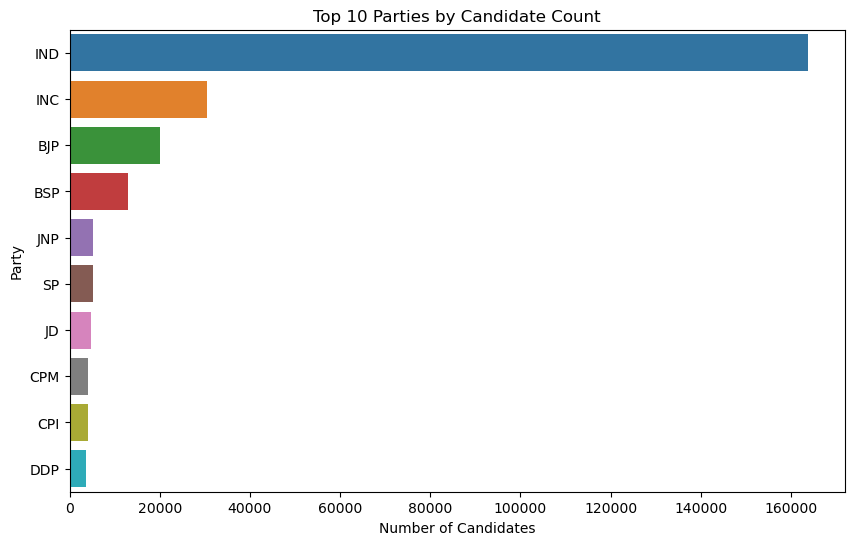

In [52]:
top10 = vid["partyabbre"].value_counts().head(10)

plt.figure(figsize=(10,6))

import seaborn as sns

sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,
    legend=False
)

plt.title("Top 10 Parties by Candidate Count")
plt.xlabel("Number of Candidates")
plt.ylabel("Party")

plt.show()

Question 13: Identify Winning Candidates

In [53]:
# Identify winner in each constituency

winners = lok.loc[
    lok.groupby(["year", "st_name", "pc_no"])["totvotpoll"].idxmax()
]

print(winners.head())

# Winners from Gujarat
gujarat_winners = winners[winners["st_name"] == "Gujarat"]

print(gujarat_winners.head())

                       st_name  year  pc_no                    pc_name  \
1    Andaman & Nicobar Islands  1977      1  Andaman & Nicobar Islands   
93              Andhra Pradesh  1977      1                 Srikakulam   
95              Andhra Pradesh  1977      2              Parvathipuram   
102             Andhra Pradesh  1977      3                    Bobbili   
106             Andhra Pradesh  1977      4              Visakhapatnam   

    pc_type                                     cand_name cand_sex  \
1       GEN                             Manoranjan Bhakta        M   
93      GEN                       Rajgopalarao Boddepalli        M   
95       ST  Vyrichorla Kishore Chandra Suryanarayana Deo        M   
102     GEN             Pusapati Vijayrama Gajapathi Raju        M   
106     GEN                      Dronamraju Satyanarayana        M   

                    partyname partyabbre  totvotpoll  electors  
1    Indian National Congress        INC       35400     85308  
93  

Question 14: Compare Vote Share vs Seat Share – National Level

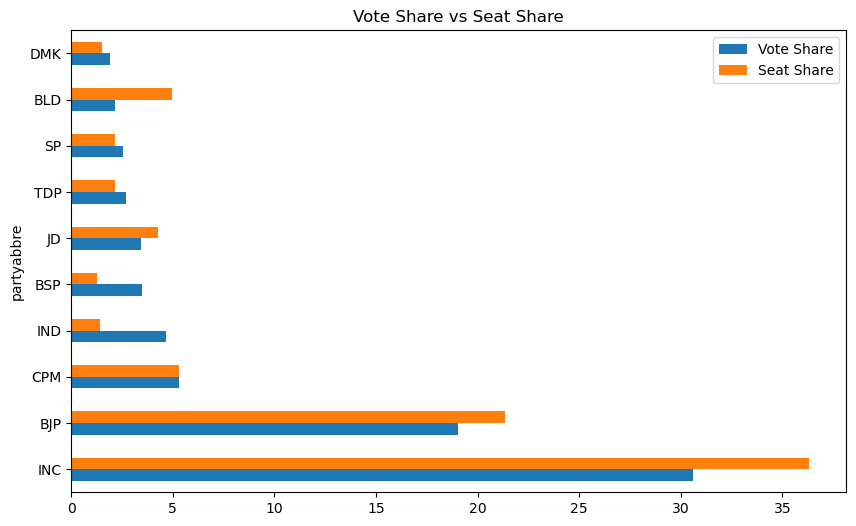

In [54]:
# Vote Share
party_votes = (
    lok.groupby("partyabbre")["totvotpoll"]
    .sum()
)

vote_share = (
    party_votes /
    party_votes.sum() * 100
)

# Seat Share
seat_share = (
    winners["partyabbre"]
    .value_counts()
)

seat_share = (
    seat_share /
    seat_share.sum() * 100
)

comparison = pd.DataFrame({
    "Vote Share": vote_share,
    "Seat Share": seat_share
}).fillna(0)

comparison = comparison.sort_values(
    "Vote Share",
    ascending=False
).head(10)

comparison.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Vote Share vs Seat Share")
plt.show()

Question 15: Gujarat – Top 3 Parties' Seat Trends Over Time

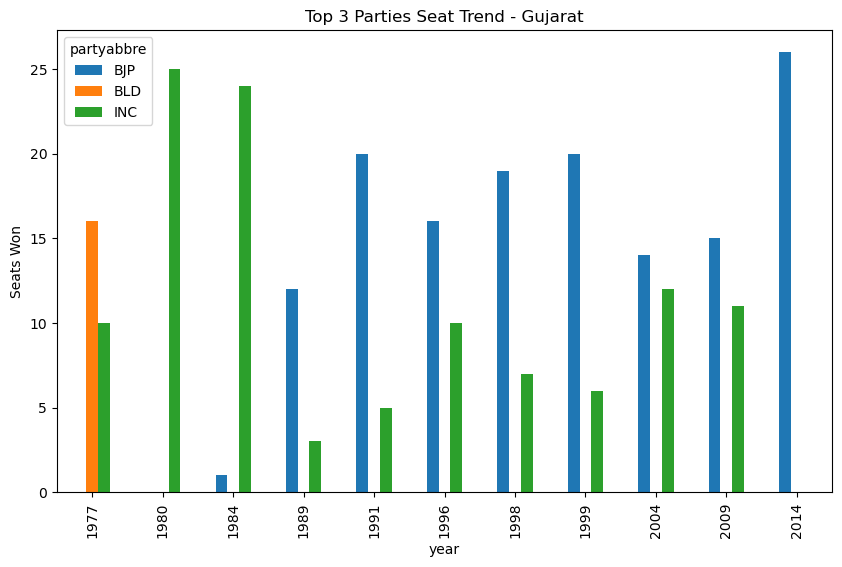

In [55]:
gujarat = winners[
    winners["st_name"] == "Gujarat"
]

top3 = (
    gujarat["partyabbre"]
    .value_counts()
    .head(3)
    .index
)

seat_trend = (
    gujarat[
        gujarat["partyabbre"].isin(top3)
    ]
    .groupby(["year", "partyabbre"])
    .size()
    .unstack(fill_value=0)
)

seat_trend.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Top 3 Parties Seat Trend - Gujarat")
plt.ylabel("Seats Won")

plt.show()

Question 16: Vote Share Trend of Top 3 Parties in Gujarat

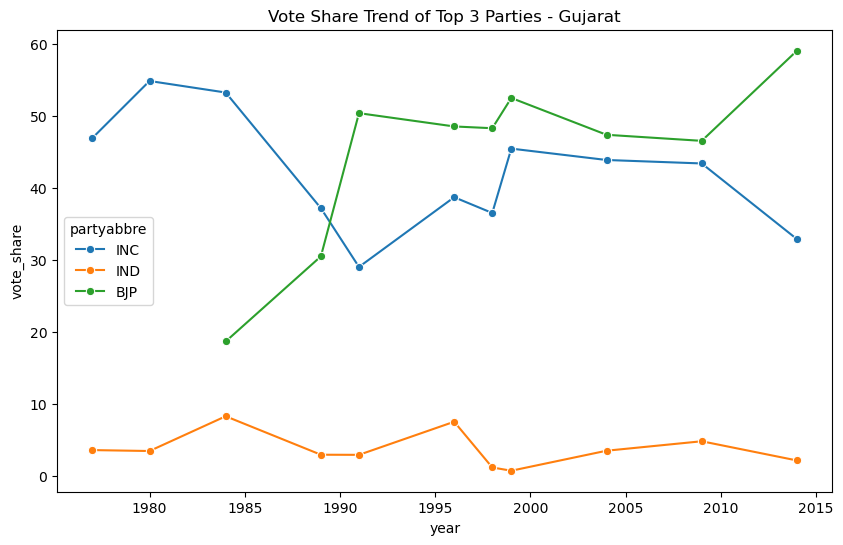

In [56]:
gujarat_all = lok[
    lok["st_name"] == "Gujarat"
]

party_votes = (
    gujarat_all.groupby(
        ["year", "partyabbre"]
    )["totvotpoll"]
    .sum()
    .reset_index()
)

total_votes = (
    gujarat_all.groupby("year")["totvotpoll"]
    .sum()
    .reset_index(name="total_votes")
)

vote_share = party_votes.merge(
    total_votes,
    on="year"
)

vote_share["vote_share"] = (
    vote_share["totvotpoll"] /
    vote_share["total_votes"] * 100
)

top3_votes = (
    vote_share.groupby("partyabbre")["totvotpoll"]
    .sum()
    .nlargest(3)
    .index
)

vote_share = vote_share[
    vote_share["partyabbre"].isin(top3_votes)
]

plt.figure(figsize=(10,6))

sns.lineplot(
    data=vote_share,
    x="year",
    y="vote_share",
    hue="partyabbre",
    marker="o"
)

plt.title("Vote Share Trend of Top 3 Parties - Gujarat")

plt.show()

Question 17: Vote Margin Analysis – Gujarat (Top 3 Parties)

In [57]:
# Gujarat data
guj = lok[lok["st_name"] == "Gujarat"].copy()

# Rank candidates
guj["Rank"] = guj.groupby(
    ["year", "pc_no"]
)["totvotpoll"].rank(
    method="first",
    ascending=False
)

# Winners
winner = guj[guj["Rank"] == 1]

# Runner-up
runner = guj[guj["Rank"] == 2]

# Merge
margin = winner.merge(
    runner,
    on=["year", "pc_no"],
    suffixes=("_winner", "_runner")
)

margin["Vote_Margin"] = (
    margin["totvotpoll_winner"] -
    margin["totvotpoll_runner"]
)

margin.head()

,st_name_winner,year,pc_no,pc_name_winner,pc_type_winner,cand_name_winner,cand_sex_winner,partyname_winner,partyabbre_winner,totvotpoll_winner,...,pc_name_runner,pc_type_runner,cand_name_runner,cand_sex_runner,partyname_runner,partyabbre_runner,totvotpoll_runner,electors_runner,Rank_runner,Vote_Margin
0,Gujarat,1977,1,Kutch,GEN,Dave Anantray Devshankar,M,Bharatiya Lok Dal,BLD,115514,...,Kutch,GEN,Mehta Mahipatray Mulshankar,M,Indian National Congress,INC,104697,438528,2.0,10817
1,Gujarat,1977,2,Surendranagar,GEN,Amin Ramdas Kishordas ( R. K. Amin ),M,Bharatiya Lok Dal,BLD,139927,...,Surendranagar,GEN,Shah Manubhai Mansukhlal,M,Indian National Congress,INC,134494,500963,2.0,5433
2,Gujarat,1977,3,Jamnagar,GEN,Vinodbhai B. Sheth,M,Bharatiya Lok Dal,BLD,121790,...,Jamnagar,GEN,Jadeja Daulatsinghji Pratapsinghji,M,Indian National Congress,INC,119120,479585,2.0,2670
3,Gujarat,1977,4,Rajkot,GEN,Patel Keshubhai Savdasbhai,M,Bharatiya Lok Dal,BLD,143051,...,Rajkot,GEN,Arvindkumar Mohanlal Patel,M,Indian National Congress,INC,127250,604102,2.0,15801
4,Gujarat,1977,5,Porbandar,GEN,Patel Dharmasinhbhai Dahyabhai,M,Bharatiya Lok Dal,BLD,143252,...,Porbandar,GEN,Dhami Ramniklal Kababhai,M,Indian National Congress,INC,118823,525285,2.0,24429


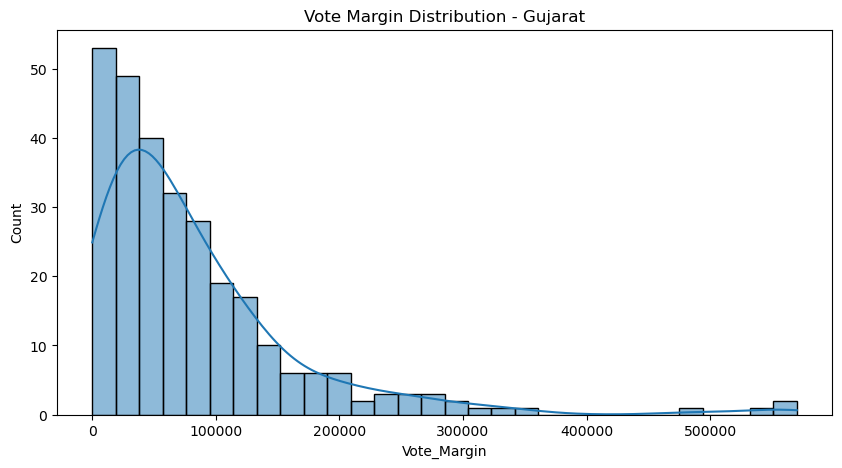

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(
    margin["Vote_Margin"],
    bins=30,
    kde=True
)

plt.title("Vote Margin Distribution - Gujarat")

plt.show()

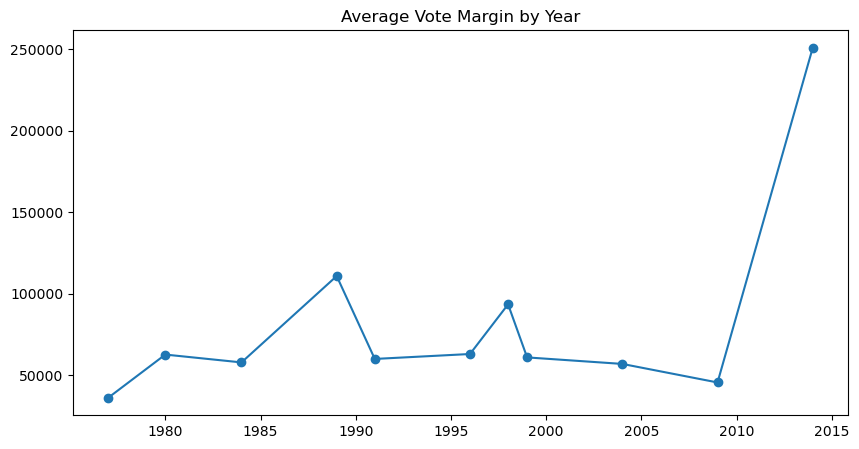

In [59]:
avg_margin = margin.groupby(
    "year"
)["Vote_Margin"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    avg_margin.index,
    avg_margin.values,
    marker="o"
)

plt.title("Average Vote Margin by Year")

plt.show()

Question 18: State-Level Voter Turnout & Constituency Analysis

In [60]:
state_turnout = (
    lok.groupby(["st_name","year","pc_no"])
    .agg({
        "totvotpoll":"max",
        "electors":"max"
    })
    .reset_index()
)

state = state_turnout.groupby("st_name").sum()

state["Turnout"] = (
    state["totvotpoll"] /
    state["electors"] * 100
)

state = state.sort_values(
    "Turnout",
    ascending=False
)

state.head()

,year,pc_no,totvotpoll,electors,Turnout
st_name,,,,,
Nagaland,21941,11,4788951,9458533,50.631012
Tripura,43882,33,7953935,17850899,44.557616
Sikkim,21941,11,1094886,2460148,44.504883
Lakshadweep,21941,11,161595,366692,44.068319
Delhi,13888,28,1528252,3496781,43.704539


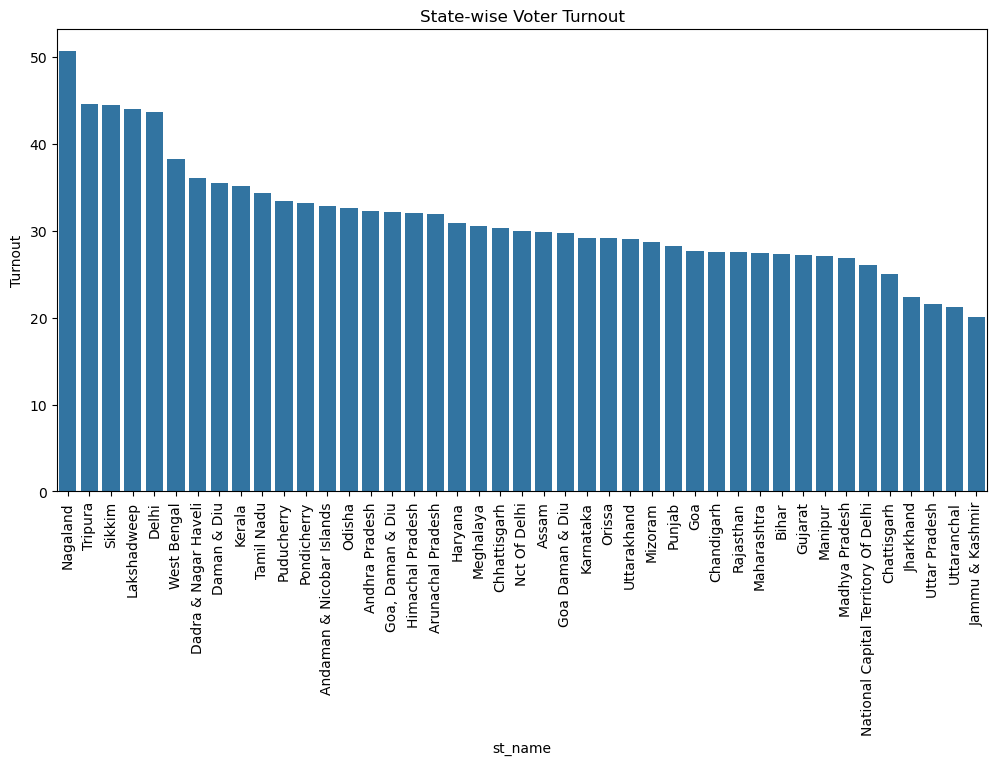

In [61]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=state.index,
    y=state["Turnout"]
)

plt.xticks(rotation=90)

plt.title("State-wise Voter Turnout")

plt.show()

Question 19: Gender-Based Participation & Performance – Lok Sabha

In [62]:
candidate_gender = (
    lok["cand_sex"]
    .value_counts()
)

winner_gender = (
    winners["cand_sex"]
    .value_counts()
)

gender = pd.DataFrame({
    "Candidates":candidate_gender,
    "Winners":winner_gender
}).fillna(0)

gender["Win Rate"] = (
    gender["Winners"] /
    gender["Candidates"] * 100
)

gender

,Candidates,Winners,Win Rate
cand_sex,,,
F,3648,455.0,12.472588
M,68885,5479.0,7.953836
O,6,0.0,0.000000
U,542,0.0,0.000000


Question 20: Visual Analysis of Gender-Based Participation

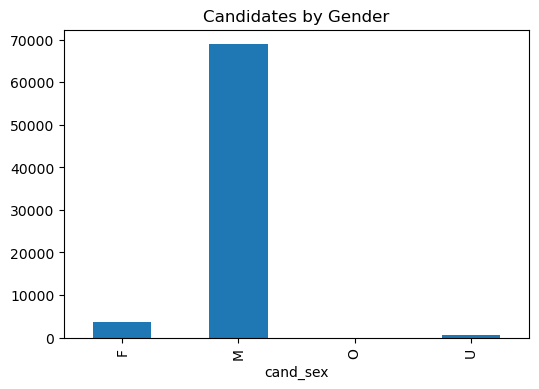

In [63]:
gender["Candidates"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Candidates by Gender")

plt.show()

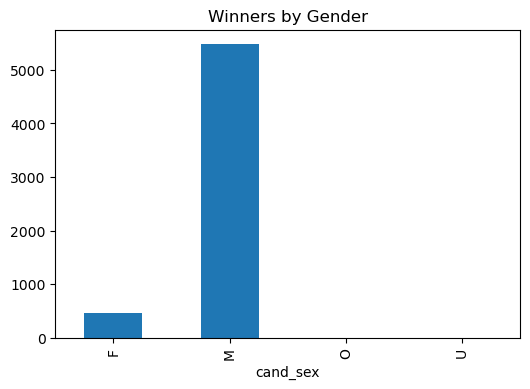

In [64]:
gender["Winners"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Winners by Gender")

plt.show()

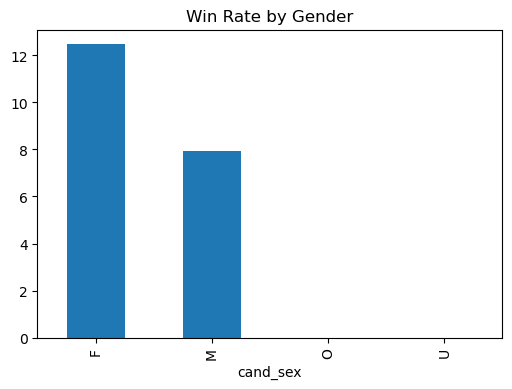

In [65]:
gender["Win Rate"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Win Rate by Gender")

plt.show()

Question 21: Seats Won by Top 5 Parties – Lok Sabha

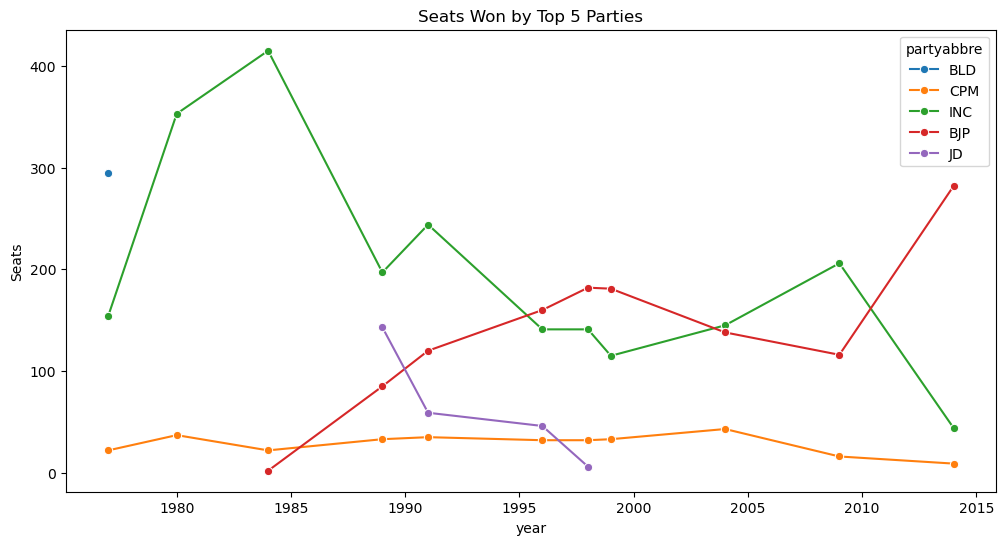

In [66]:
# Winners already created in Question 13

seat_year = (
    winners.groupby(["year", "partyabbre"])
    .size()
    .reset_index(name="Seats")
)

top5 = (
    seat_year.groupby("partyabbre")["Seats"]
    .sum()
    .nlargest(5)
    .index
)

seat_top5 = seat_year[
    seat_year["partyabbre"].isin(top5)
]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=seat_top5,
    x="year",
    y="Seats",
    hue="partyabbre",
    marker="o"
)

plt.title("Seats Won by Top 5 Parties")

plt.show()

Question 22: Vote Share Trend of Top 5 Parties – Lok Sabha

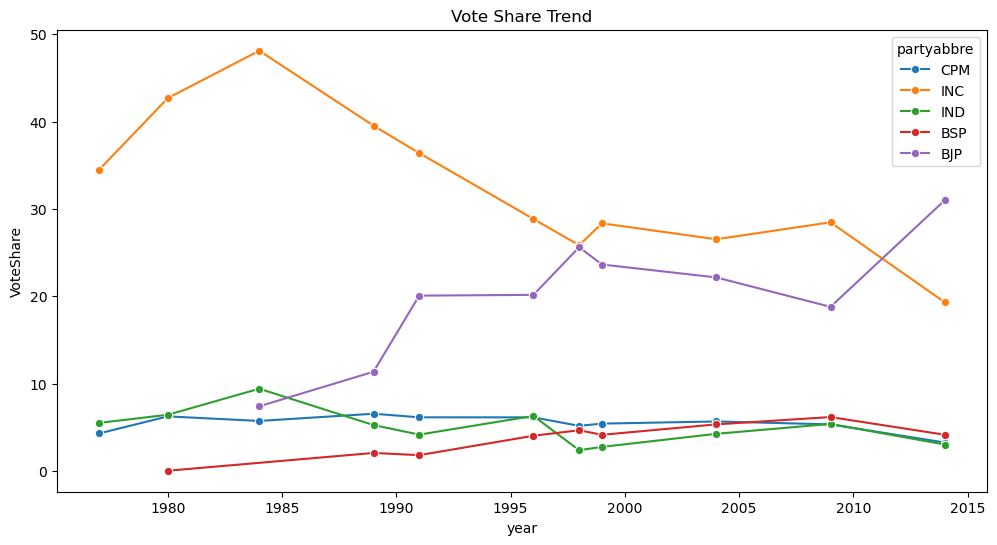

In [67]:
party_votes = (
    lok.groupby(["year","partyabbre"])["totvotpoll"]
    .sum()
    .reset_index()
)

total_votes = (
    lok.groupby("year")["totvotpoll"]
    .sum()
    .reset_index(name="TotalVotes")
)

vote = party_votes.merge(total_votes,on="year")

vote["VoteShare"] = (
    vote["totvotpoll"] /
    vote["TotalVotes"] * 100
)

top5_vote = (
    vote.groupby("partyabbre")["totvotpoll"]
    .sum()
    .nlargest(5)
    .index
)

vote = vote[vote["partyabbre"].isin(top5_vote)]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=vote,
    x="year",
    y="VoteShare",
    hue="partyabbre",
    marker="o"
)

plt.title("Vote Share Trend")

plt.show()

Question 23: Gini Coefficient of Vote Distribution – Lok Sabha

Overall Gini: 0.8173004018622133


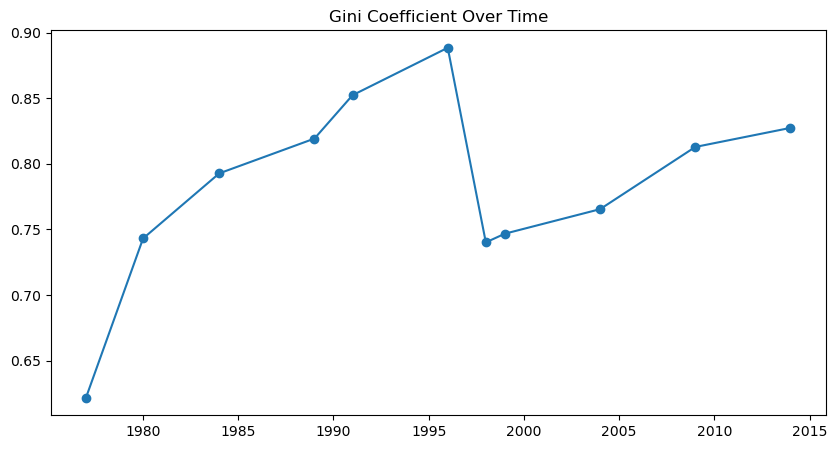

In [68]:
def gini(x):
    x = np.sort(np.array(x))
    n = len(x)

    return (
        np.sum((2*np.arange(1,n+1)-n-1)*x)
        /(n*np.sum(x))
    )

overall_gini = gini(lok["totvotpoll"])

print("Overall Gini:",overall_gini)

gini_year = (
    lok.groupby("year")["totvotpoll"]
    .apply(gini)
)

plt.figure(figsize=(10,5))

plt.plot(
    gini_year.index,
    gini_year.values,
    marker="o"
)

plt.title("Gini Coefficient Over Time")

plt.show()

Question 24: Lorenz Curve of Vote Distribution – Lok Sabha

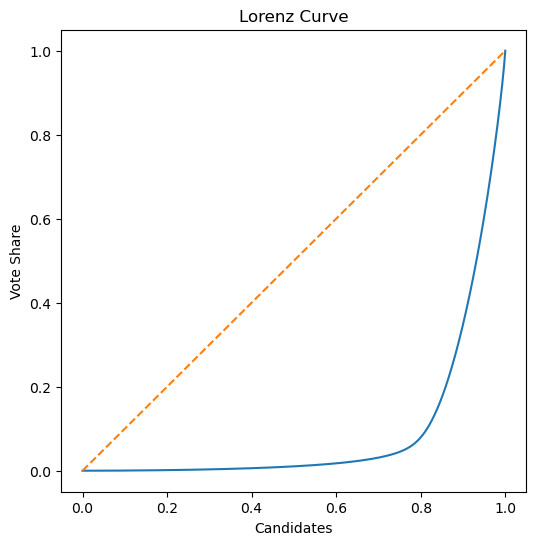

In [69]:
votes = np.sort(
    lok["totvotpoll"][lok["totvotpoll"]>0]
)

cum_votes = np.cumsum(votes)

cum_votes = cum_votes / cum_votes[-1]

cum_people = np.arange(1,len(votes)+1) / len(votes)

plt.figure(figsize=(6,6))

plt.plot(cum_people,cum_votes)

plt.plot([0,1],[0,1],'--')

plt.title("Lorenz Curve")

plt.xlabel("Candidates")

plt.ylabel("Vote Share")

plt.show()

Question 25: Skewness and Kurtosis of Vote Share – Lok Sabha

In [70]:
lok["VoteShare"] = (
    lok["totvotpoll"] /
    lok["electors"] * 100
)

lok = lok[
    (lok["VoteShare"]>=0) &
    (lok["VoteShare"]<=100)
]

print("Skewness:",
      skew(lok["VoteShare"]))

print("Kurtosis:",
      kurtosis(lok["VoteShare"]))

Skewness: 2.218681193085088
Kurtosis: 4.047808053014867


Question 26: Skewness & Kurtosis Over Time – Lok Sabha

      Skewness   Kurtosis
year                     
1977  0.869836  -0.487988
1980  1.733725   1.986911
1984  1.914409   2.355135
1989  2.136984   3.499113
1991  2.810178   7.671801
1996  3.636894  13.781332
1998  1.389376   0.551309
1999  1.446932   0.728694
2004  1.884250   2.647415
2009  2.530822   5.828738
2014  2.496316   5.303818


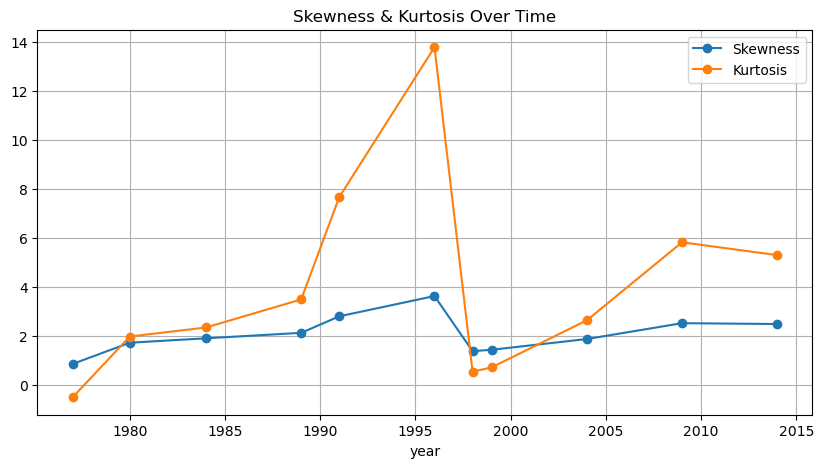

In [71]:
stats_year = (
    lok.groupby("year")["VoteShare"]
    .agg(
        Skewness=lambda x: skew(x),
        Kurtosis=lambda x: kurtosis(x)
    )
)

print(stats_year)

stats_year.plot(
    figsize=(10,5),
    marker="o"
)

plt.title("Skewness & Kurtosis Over Time")
plt.grid(True)
plt.show()

Question 27: Party-wise Skewness & Kurtosis of Vote Share

In [72]:
party_vote = (
    lok.groupby(["year","partyabbre"])["totvotpoll"]
    .sum()
    .reset_index()
)

total = (
    lok.groupby("year")["totvotpoll"]
    .sum()
    .reset_index(name="Total")
)

party_vote = party_vote.merge(total,on="year")

party_vote["VoteShare"] = (
    party_vote["totvotpoll"] /
    party_vote["Total"] * 100
)

valid = (
    party_vote.groupby("partyabbre")
    .filter(lambda x: len(x)>=3)
)

party_stats = (
    valid.groupby("partyabbre")["VoteShare"]
    .agg(
        Skewness=lambda x: skew(x),
        Kurtosis=lambda x: kurtosis(x)
    )
)

party_stats.sort_values("Skewness",ascending=False).head()

,Skewness,Kurtosis
partyabbre,,
SAD(M),2.174604,2.915587
SSD,2.108498,3.223395
JP,1.778669,1.181883
ABJS,1.589929,0.862739
JKP,1.561140,1.392361


Question 28: Party-wise Skewness & Kurtosis Visualization

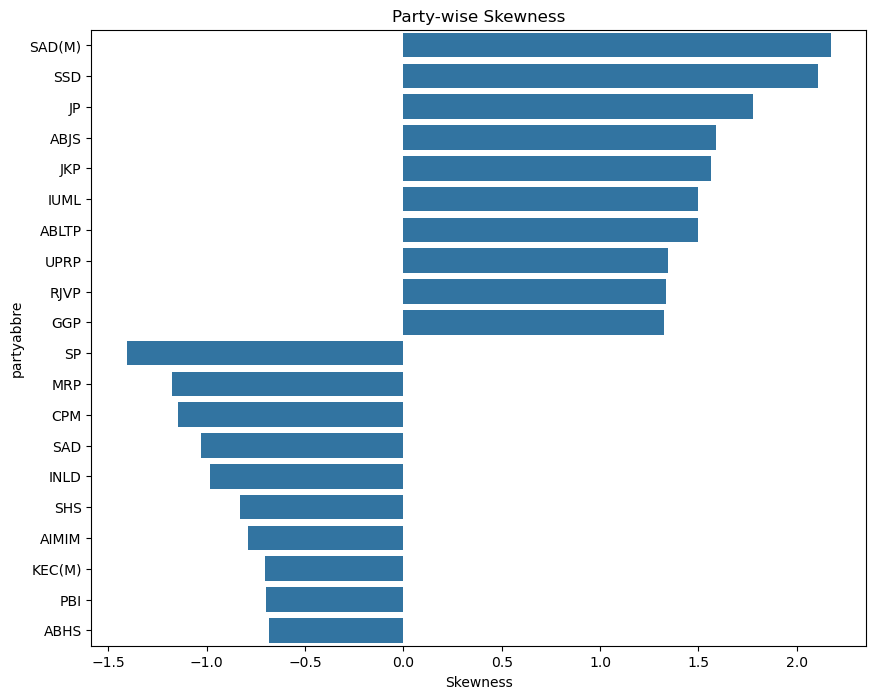

In [73]:
top10 = party_stats.sort_values(
    "Skewness",
    ascending=False
).head(10)

bottom10 = party_stats.sort_values(
    "Skewness"
).head(10)

plot_data = pd.concat([top10,bottom10])

plt.figure(figsize=(10,8))

sns.barplot(
    data=plot_data,
    x="Skewness",
    y=plot_data.index
)

plt.title("Party-wise Skewness")

plt.show()

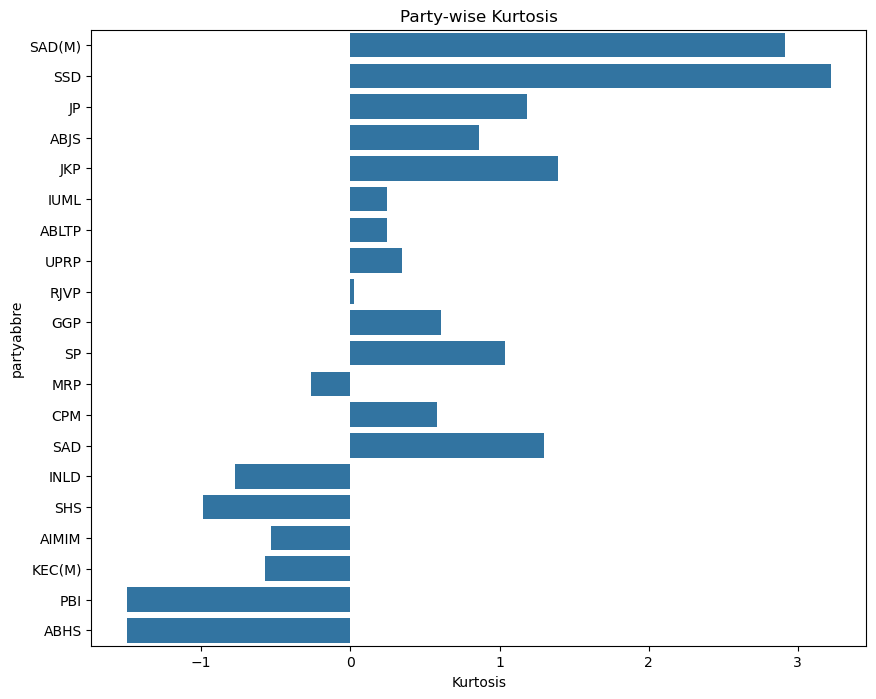

In [74]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=plot_data,
    x="Kurtosis",
    y=plot_data.index
)

plt.title("Party-wise Kurtosis")

plt.show()

Question 29: ANOVA Analysis of Party Vote Share Across States

In [75]:
party = "BJP"

bjp = lok[lok["partyabbre"]==party].copy()

bjp["VoteShare"] = (
    bjp["totvotpoll"] /
    bjp["electors"] * 100
)

groups = [
    g["VoteShare"].values
    for _,g in bjp.groupby("st_name")
    if len(g)>=3
]

f,p = f_oneway(*groups)

print("F Statistic:",f)
print("P Value:",p)

F Statistic: 49.87972692301077
P Value: 1.762105656309675e-273


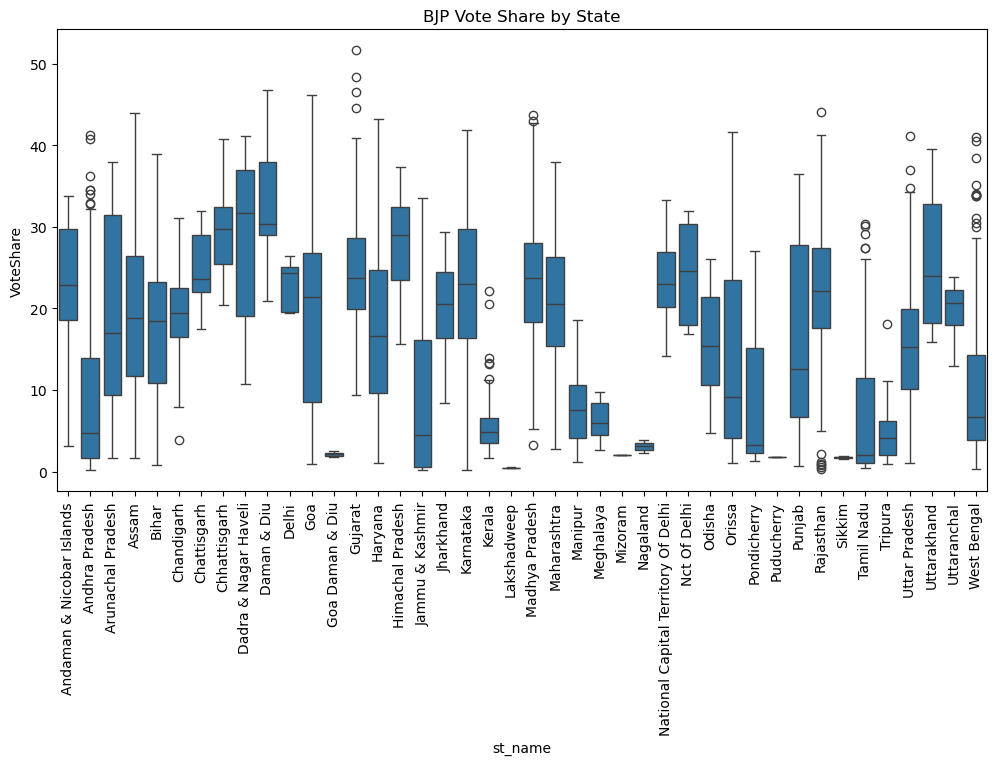

In [76]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=bjp,
    x="st_name",
    y="VoteShare"
)

plt.xticks(rotation=90)

plt.title("BJP Vote Share by State")

plt.show()

Question 30: Statistical Comparison of Vote Share – Ruling vs Opposition

In [77]:
party_vote["Group"] = np.where(
    party_vote["partyabbre"]=="BJP",
    "Ruling",
    "Opposition"
)

ruling = party_vote[
    party_vote["Group"]=="Ruling"
]["VoteShare"]

opposition = party_vote[
    party_vote["Group"]=="Opposition"
]["VoteShare"]

t,p = ttest_ind(
    ruling,
    opposition,
    equal_var=False
)

print("T Statistic:",t)
print("P Value:",p)

T Statistic: 8.236835194782248
P Value: 3.5069802531036166e-05


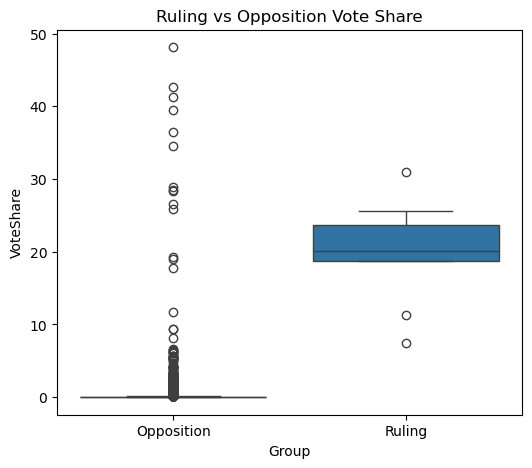

In [78]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=party_vote,
    x="Group",
    y="VoteShare"
)

plt.title("Ruling vs Opposition Vote Share")

plt.show()

Question 31: Party-Wise Vote Share Correlation Analysis

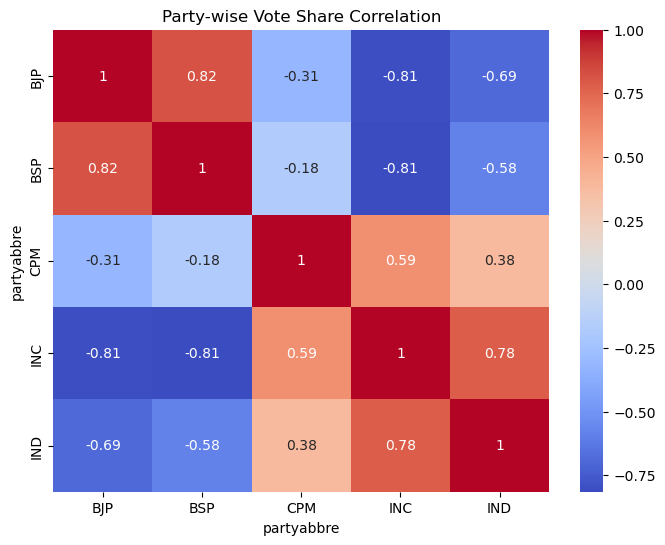

In [79]:
party_votes = (
    lok.groupby(["year", "partyabbre"])["totvotpoll"]
    .sum()
    .reset_index(name="party_votes")
)

total_votes = (
    lok.groupby("year")["totvotpoll"]
    .sum()
    .reset_index(name="total_votes")
)

vote_share = party_votes.merge(total_votes, on="year")

vote_share["vote_share_percent"] = (
    vote_share["party_votes"] /
    vote_share["total_votes"] * 100
)

top5 = (
    vote_share.groupby("partyabbre")["party_votes"]
    .sum()
    .nlargest(5)
    .index
)

vote_share = vote_share[
    vote_share["partyabbre"].isin(top5)
]

pivot = vote_share.pivot(
    index="year",
    columns="partyabbre",
    values="vote_share_percent"
).fillna(0)

corr = pivot.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Party-wise Vote Share Correlation")
plt.show()

Question 32: Calculate Vote Share Percentage of Each Political Party

In [80]:
party_votes = (
    lok.groupby(["year","partyabbre"])["totvotpoll"]
    .sum()
    .reset_index(name="party_votes")
)

total_votes = (
    lok.groupby("year")["totvotpoll"]
    .sum()
    .reset_index(name="total_votes")
)

vote_share = party_votes.merge(
    total_votes,
    on="year"
)

vote_share["vote_share_percent"] = (
    vote_share["party_votes"] /
    vote_share["total_votes"] * 100
)

vote_share.head()

,year,partyabbre,party_votes,total_votes,vote_share_percent
0,1977,ADK,5480378,188917504,2.900937
1,1977,BLD,78062828,188917504,41.321120
2,1977,CPI,5322088,188917504,2.817149
3,1977,CPM,8113659,188917504,4.294816
4,1977,DMK,3323320,188917504,1.759138


Question 33: Vote Share Trends of Top 5 Parties Over Time

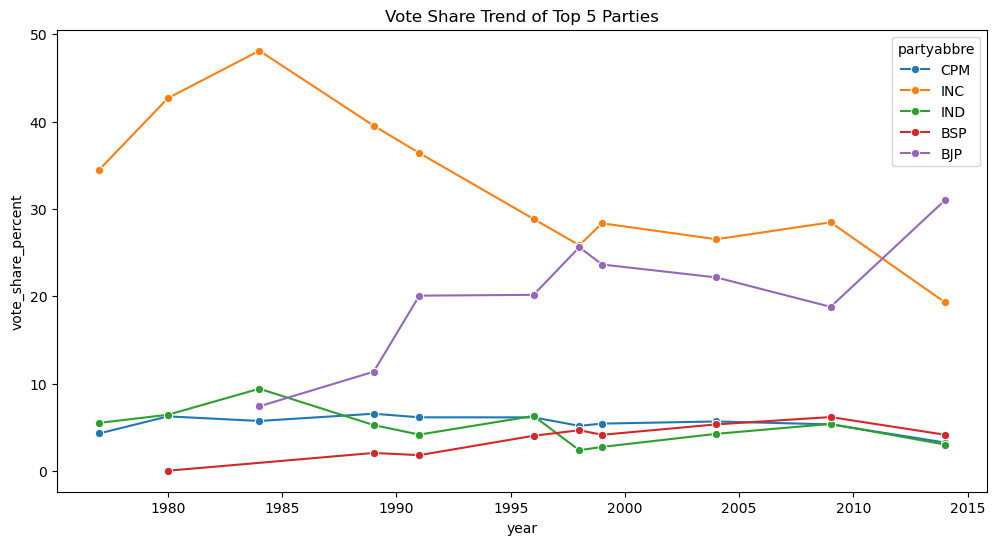

In [81]:
top5 = (
    vote_share.groupby("partyabbre")["party_votes"]
    .sum()
    .nlargest(5)
    .index
)

plot_data = vote_share[
    vote_share["partyabbre"].isin(top5)
]

plt.figure(figsize=(12,6))

sns.lineplot(
    data=plot_data,
    x="year",
    y="vote_share_percent",
    hue="partyabbre",
    marker="o"
)

plt.title("Vote Share Trend of Top 5 Parties")
plt.show()

Question 34: Tracking Incumbency Retention in Lok Sabha Elections

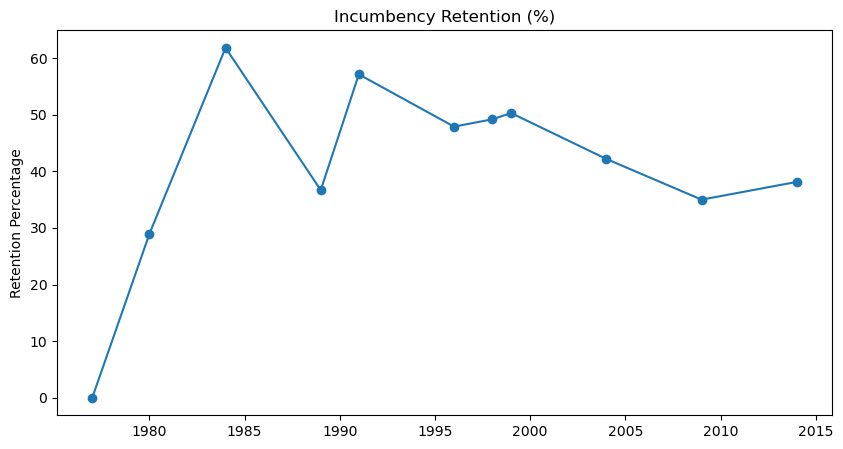

In [82]:
winners = lok.loc[
    lok.groupby(
        ["year","st_name","pc_no"]
    )["totvotpoll"].idxmax()
]

winners = winners.sort_values(
    ["st_name","pc_no","year"]
)

winners["PreviousParty"] = (
    winners.groupby(
        ["st_name","pc_no"]
    )["partyabbre"].shift(1)
)

winners["Retained"] = (
    winners["partyabbre"] ==
    winners["PreviousParty"]
)

retention = (
    winners.groupby("year")["Retained"]
    .mean()*100
)

plt.figure(figsize=(10,5))

plt.plot(
    retention.index,
    retention.values,
    marker="o"
)

plt.title("Incumbency Retention (%)")
plt.ylabel("Retention Percentage")

plt.show()

Question 35: Measuring Vote Share Swing for Top Political Parties

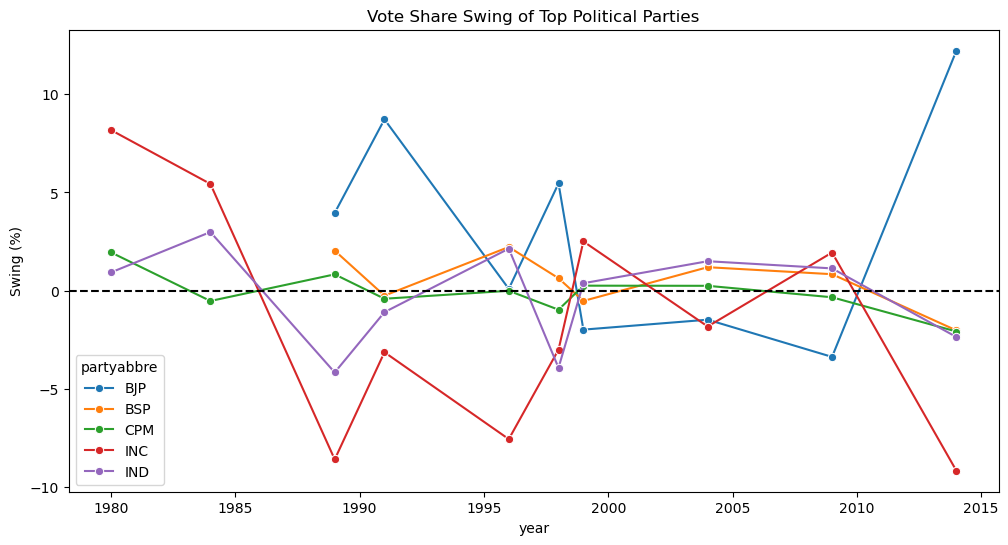

In [83]:
top5 = (
    vote_share.groupby("partyabbre")["party_votes"]
    .sum()
    .nlargest(5)
    .index
)

swing = vote_share[
    vote_share["partyabbre"].isin(top5)
].copy()

swing = swing.sort_values(
    ["partyabbre","year"]
)

swing["Swing"] = (
    swing.groupby("partyabbre")["vote_share_percent"]
    .diff()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=swing,
    x="year",
    y="Swing",
    hue="partyabbre",
    marker="o"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.title("Vote Share Swing of Top Political Parties")
plt.ylabel("Swing (%)")

plt.show()